## MLP on alpha * topo + bio

In [ ]:
# Cell 1: imports & data
import numpy as np
import torch, torch.nn as nn
from utils import load_dataset, delong_roc_test, plot_metric_bars, run_cv_bio_vs_biotopo
import matplotlib.pyplot as plt


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
rng_seed = 13

# Load per-view datasets (separate files)
Xb_tr, y_tr, Xb_te, y_te, b_cols = load_dataset("../datasets/BioFeats")
Xt_tr, yt_tr, Xt_te, yt_te, t_cols = load_dataset("../datasets/TopoFeats_BioEmb")
assert np.all(y_tr==yt_tr) and np.all(y_te==yt_te)

train_cfg = dict(hidden=(256,128), pdrop=0.1, epochs=20, batch_size=256,
                 lr=1e-3, weight_decay=1e-4, patience=5, min_delta=5e-4, seed=13)

### alpha = 2 with mode="concat"

In [2]:
alpha = 2
out = run_cv_bio_vs_biotopo(Xb_tr, Xt_tr, y_tr, alpha=alpha, mode="concat",
                                     n_splits=5, n_repeats=5, undersample=True,
                                     base_seed=13, train_cfg=train_cfg)

print(out["summary"]["Bio"])
print(out["summary"]["BioTopo"])

# DeLong on pooled OOF
res = delong_roc_test(out["delong_ready"]["y"], out["delong_ready"]["bio"], out["delong_ready"]["biotopo"])
print(f"AUC(bio)={res['auc_a']:.4f}  AUC(bio+topo)={res['auc_b']:.4f}  Δ={res['delta']:.4f}  p={res['p']:.3g}")


{'AUC_mean': 0.9493675567007742, 'AUC_std': 0.001130782825324547, 'AP_mean': 0.9995398367863576, 'AP_std': 1.1906896821385005e-05, 'F1_mean': 0.9288311227306977, 'F1_std': 0.003241968884055596, 'ACC_mean': 0.8681203653555322, 'ACC_std': 0.0056355138993411675, 'PREC_mean': 0.9990759075661098, 'PREC_std': 1.729202442202307e-05, 'REC_mean': 0.8679141470896463, 'REC_std': 0.005684702004294668}
{'AUC_mean': 0.9581797960789237, 'AUC_std': 0.0010824369720951936, 'AP_mean': 0.9996281942572407, 'AP_std': 1.1683244030319606e-05, 'F1_mean': 0.9423661031971108, 'F1_std': 0.0045178443041935116, 'ACC_mean': 0.891978171236366, 'ACC_std': 0.007968819843647177, 'PREC_mean': 0.9990893520000773, 'PREC_std': 4.4497581140530064e-05, 'REC_mean': 0.8919668883505218, 'REC_std': 0.00805764737775046}
AUC(bio)=0.9490  AUC(bio+topo)=0.9571  Δ=0.0081  p=0.57


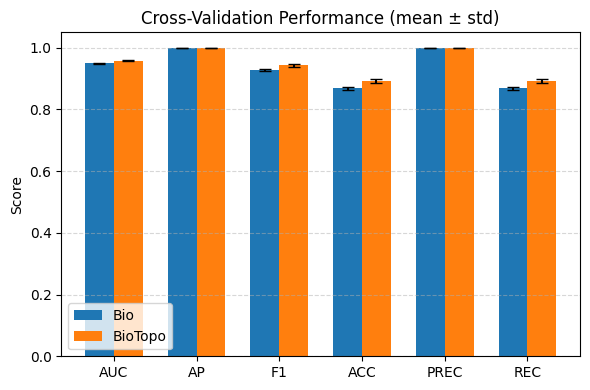

In [3]:
plot_metric_bars(
    out["summary"],
    model_labels=("Bio", "BioTopo"),   
    metrics=("AUC", "AP", "F1", "ACC", "PREC", "REC"),  
    title="Cross-Validation Performance (mean ± std)"
)
plt.show()

### alpha = 2 with mode="sym4"

In [4]:
alpha = 2
out = run_cv_bio_vs_biotopo(Xb_tr, Xt_tr, y_tr, alpha=alpha, mode="sym4",
                                     n_splits=5, n_repeats=5, undersample=True,
                                     base_seed=13, train_cfg=train_cfg)

print(out["summary"]["Bio"])
print(out["summary"]["BioTopo"])

# DeLong on pooled OOF
res = delong_roc_test(out["delong_ready"]["y"], out["delong_ready"]["bio"], out["delong_ready"]["biotopo"])
print(f"AUC(bio)={res['auc_a']:.4f}  AUC(bio+topo)={res['auc_b']:.4f}  Δ={res['delta']:.4f}  p={res['p']:.3g}")


{'AUC_mean': 0.9343138664677433, 'AUC_std': 0.0016997512171028364, 'AP_mean': 0.9993810727165263, 'AP_std': 2.183159280101789e-05, 'F1_mean': 0.9187368876969959, 'F1_std': 0.002583211607175795, 'ACC_mean': 0.8508402087546871, 'ACC_std': 0.004341699066200287, 'PREC_mean': 0.9989009813655698, 'PREC_std': 8.13779318477895e-05, 'REC_mean': 0.850635685203421, 'REC_std': 0.0043994621988799505}
{'AUC_mean': 0.9426060112310883, 'AUC_std': 0.002187820534046409, 'AP_mean': 0.9994730503207482, 'AP_std': 2.5884486261027285e-05, 'F1_mean': 0.9253012998740304, 'F1_std': 0.007766300569228178, 'ACC_mean': 0.8622122187958119, 'ACC_std': 0.013214468145455861, 'PREC_mean': 0.9989911135081856, 'PREC_std': 8.256448161097567e-05, 'REC_mean': 0.8620299821141142, 'REC_std': 0.013384104667958327}
AUC(bio)=0.9334  AUC(bio+topo)=0.9413  Δ=0.0080  p=0.634


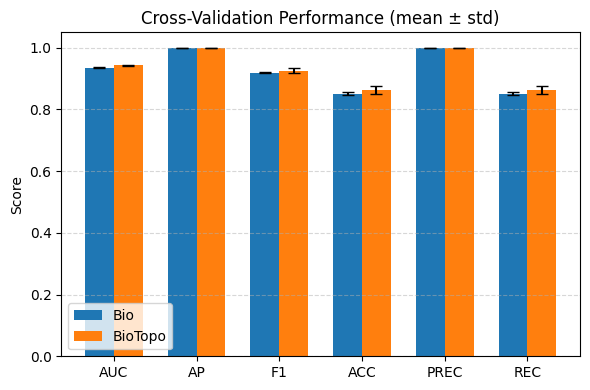

In [5]:
plot_metric_bars(
    out["summary"],
    model_labels=("Bio", "BioTopo"),   
    metrics=("AUC", "AP", "F1", "ACC", "PREC", "REC"),  
    title="Cross-Validation Performance (mean ± std)"
)
plt.show()

### alpha = 4 with mode="concat"

In [6]:
alpha = 4
out = run_cv_bio_vs_biotopo(Xb_tr, Xt_tr, y_tr, alpha=alpha, mode="concat",
                                     n_splits=5, n_repeats=5, undersample=True,
                                     base_seed=13, train_cfg=train_cfg)

print(out["summary"]["Bio"])
print(out["summary"]["BioTopo"])

# DeLong on pooled OOF
res = delong_roc_test(out["delong_ready"]["y"], out["delong_ready"]["bio"], out["delong_ready"]["biotopo"])
print(f"AUC(bio)={res['auc_a']:.4f}  AUC(bio+topo)={res['auc_b']:.4f}  Δ={res['delta']:.4f}  p={res['p']:.3g}")


{'AUC_mean': 0.9493675567007742, 'AUC_std': 0.001130782825324547, 'AP_mean': 0.9995398367863576, 'AP_std': 1.1906896821385005e-05, 'F1_mean': 0.9288311227306977, 'F1_std': 0.003241968884055596, 'ACC_mean': 0.8681203653555322, 'ACC_std': 0.0056355138993411675, 'PREC_mean': 0.9990759075661098, 'PREC_std': 1.729202442202307e-05, 'REC_mean': 0.8679141470896463, 'REC_std': 0.005684702004294668}
{'AUC_mean': 0.9591703475452347, 'AUC_std': 0.0009140755185137285, 'AP_mean': 0.9996350782131991, 'AP_std': 9.858361075181406e-06, 'F1_mean': 0.9431784962424079, 'F1_std': 0.003623884719829538, 'ACC_mean': 0.8933719938606342, 'ACC_std': 0.0063829959310003825, 'PREC_mean': 0.9990961797738622, 'PREC_std': 7.235320805656747e-05, 'REC_mean': 0.8933654593931852, 'REC_std': 0.006500034060930256}
AUC(bio)=0.9490  AUC(bio+topo)=0.9584  Δ=0.0094  p=0.56


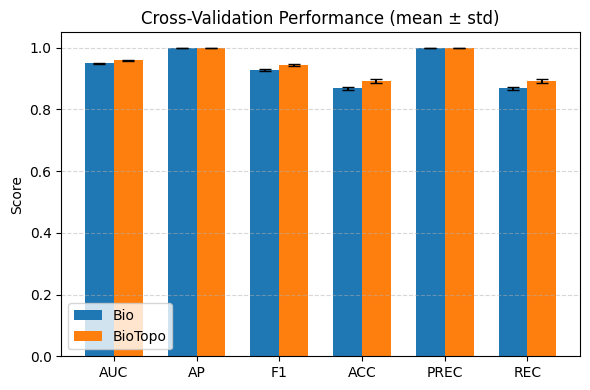

In [7]:
plot_metric_bars(
    out["summary"],
    model_labels=("Bio", "BioTopo"),   
    metrics=("AUC", "AP", "F1", "ACC", "PREC", "REC"),  
    title="Cross-Validation Performance (mean ± std)"
)
plt.show()

### alpha = 4 with mode="sym4"

In [8]:
alpha = 4
out = run_cv_bio_vs_biotopo(Xb_tr, Xt_tr, y_tr, alpha=alpha, mode="sym4",
                                     n_splits=5, n_repeats=5, undersample=True,
                                     base_seed=13, train_cfg=train_cfg)

print(out["summary"]["Bio"])
print(out["summary"]["BioTopo"])

# DeLong on pooled OOF
res = delong_roc_test(out["delong_ready"]["y"], out["delong_ready"]["bio"], out["delong_ready"]["biotopo"])
print(f"AUC(bio)={res['auc_a']:.4f}  AUC(bio+topo)={res['auc_b']:.4f}  Δ={res['delta']:.4f}  p={res['p']:.3g}")


{'AUC_mean': 0.9343138664677433, 'AUC_std': 0.0016997512171028364, 'AP_mean': 0.9993810727165263, 'AP_std': 2.183159280101789e-05, 'F1_mean': 0.9187368876969959, 'F1_std': 0.002583211607175795, 'ACC_mean': 0.8508402087546871, 'ACC_std': 0.004341699066200287, 'PREC_mean': 0.9989009813655698, 'PREC_std': 8.13779318477895e-05, 'REC_mean': 0.850635685203421, 'REC_std': 0.0043994621988799505}
{'AUC_mean': 0.9403233971860496, 'AUC_std': 0.002184766615040648, 'AP_mean': 0.9994361272264379, 'AP_std': 2.5095746836411422e-05, 'F1_mean': 0.925913280848197, 'F1_std': 0.01039494199571351, 'ACC_mean': 0.8634348142669184, 'ACC_std': 0.017809988433433253, 'PREC_mean': 0.9989381786750325, 'PREC_std': 0.00016497529188387762, 'REC_mean': 0.8633130283921593, 'REC_std': 0.01809945593250185}
AUC(bio)=0.9334  AUC(bio+topo)=0.9385  Δ=0.0051  p=0.786


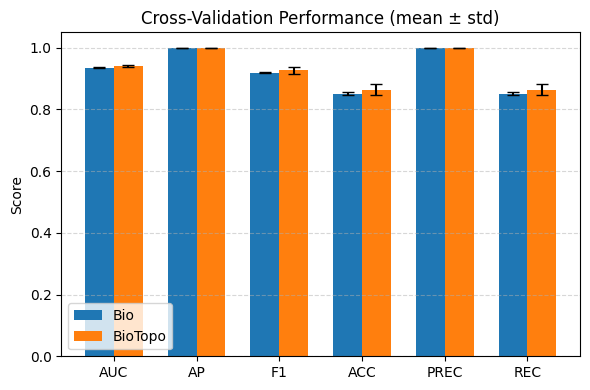

In [9]:
plot_metric_bars(
    out["summary"],
    model_labels=("Bio", "BioTopo"),   
    metrics=("AUC", "AP", "F1", "ACC", "PREC", "REC"),  
    title="Cross-Validation Performance (mean ± std)"
)
plt.show()

### alpha = 8 with mode="concat"

In [10]:
alpha = 8
out = run_cv_bio_vs_biotopo(Xb_tr, Xt_tr, y_tr, alpha=alpha, mode="concat",
                                     n_splits=5, n_repeats=5, undersample=True,
                                     base_seed=13, train_cfg=train_cfg)

print(out["summary"]["Bio"])
print(out["summary"]["BioTopo"])

# DeLong on pooled OOF
res = delong_roc_test(out["delong_ready"]["y"], out["delong_ready"]["bio"], out["delong_ready"]["biotopo"])
print(f"AUC(bio)={res['auc_a']:.4f}  AUC(bio+topo)={res['auc_b']:.4f}  Δ={res['delta']:.4f}  p={res['p']:.3g}")


{'AUC_mean': 0.9493675567007742, 'AUC_std': 0.001130782825324547, 'AP_mean': 0.9995398367863576, 'AP_std': 1.1906896821385005e-05, 'F1_mean': 0.9288311227306977, 'F1_std': 0.003241968884055596, 'ACC_mean': 0.8681203653555322, 'ACC_std': 0.0056355138993411675, 'PREC_mean': 0.9990759075661098, 'PREC_std': 1.729202442202307e-05, 'REC_mean': 0.8679141470896463, 'REC_std': 0.005684702004294668}
{'AUC_mean': 0.9562775118337477, 'AUC_std': 0.0006696920428049463, 'AP_mean': 0.999605619259506, 'AP_std': 6.880173589656412e-06, 'F1_mean': 0.9337874884014715, 'F1_std': 0.009662869822284204, 'ACC_mean': 0.8770953589578692, 'ACC_std': 0.016627255976688026, 'PREC_mean': 0.9991623505957857, 'PREC_std': 0.00011138115727703612, 'REC_mean': 0.876893828087612, 'REC_std': 0.016861217698654063}
AUC(bio)=0.9490  AUC(bio+topo)=0.9548  Δ=0.0058  p=0.748


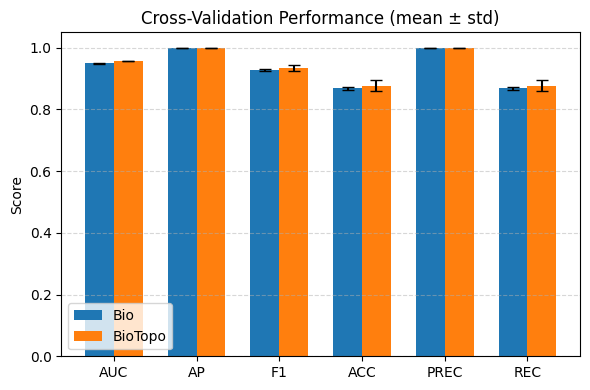

In [11]:
plot_metric_bars(
    out["summary"],
    model_labels=("Bio", "BioTopo"),   
    metrics=("AUC", "AP", "F1", "ACC", "PREC", "REC"),  
    title="Cross-Validation Performance (mean ± std)"
)
plt.show()

### alpha = 8 with mode="sym4"

In [12]:
alpha = 8
out = run_cv_bio_vs_biotopo(Xb_tr, Xt_tr, y_tr, alpha=alpha, mode="sym4",
                                     n_splits=5, n_repeats=5, undersample=True,
                                     base_seed=13, train_cfg=train_cfg)

print(out["summary"]["Bio"])
print(out["summary"]["BioTopo"])

# DeLong on pooled OOF
res = delong_roc_test(out["delong_ready"]["y"], out["delong_ready"]["bio"], out["delong_ready"]["biotopo"])
print(f"AUC(bio)={res['auc_a']:.4f}  AUC(bio+topo)={res['auc_b']:.4f}  Δ={res['delta']:.4f}  p={res['p']:.3g}")


{'AUC_mean': 0.9343138664677433, 'AUC_std': 0.0016997512171028364, 'AP_mean': 0.9993810727165263, 'AP_std': 2.183159280101789e-05, 'F1_mean': 0.9187368876969959, 'F1_std': 0.002583211607175795, 'ACC_mean': 0.8508402087546871, 'ACC_std': 0.004341699066200287, 'PREC_mean': 0.9989009813655698, 'PREC_std': 8.13779318477895e-05, 'REC_mean': 0.850635685203421, 'REC_std': 0.0043994621988799505}
{'AUC_mean': 0.9168166498640209, 'AUC_std': 0.0016132290267350945, 'AP_mean': 0.9992007642419967, 'AP_std': 1.8126772951560903e-05, 'F1_mean': 0.8967826649947981, 'F1_std': 0.012249900409790827, 'ACC_mean': 0.8147887531565811, 'ACC_std': 0.019884769556743315, 'PREC_mean': 0.9987159682535468, 'PREC_std': 0.00014982822400899458, 'REC_mean': 0.8144272884360045, 'REC_std': 0.020177741605429435}
AUC(bio)=0.9334  AUC(bio+topo)=0.9144  Δ=-0.0190  p=0.37


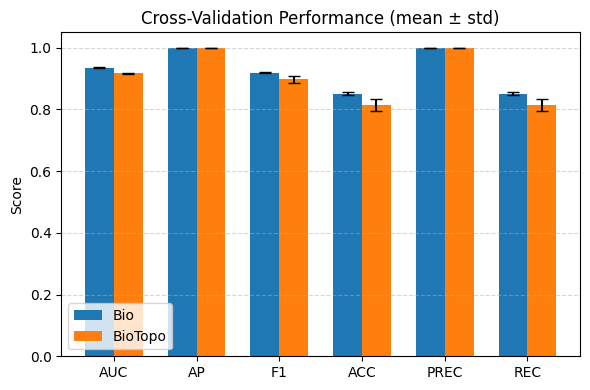

In [13]:
plot_metric_bars(
    out["summary"],
    model_labels=("Bio", "BioTopo"),   
    metrics=("AUC", "AP", "F1", "ACC", "PREC", "REC"),  
    title="Cross-Validation Performance (mean ± std)"
)
plt.show()